# If running this notebook on google colab, **change runtime type** and choose T4 gpu.
If running on mac with M chips, you will need to change the device to 'mpu'

In [118]:
import copy
import torch
import sklearn
import numpy as np
import pandas as pd
from torch import nn
from tqdm.notebook import tqdm
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
# Test whether the notebook is running on google colab or not, and set the data path accordingly
import os
if os.getenv("COLAB_RELEASE_TAG") is None:
    DATA_IN_PATH = '../data'
else:
    DATA_IN_PATH = 'https://raw.githubusercontent.com/rguilcas/BCCR-ML-course/refs/heads/main/lecture_exercises/data'

# Choose seeds for reproducibility
torch.manual_seed(0)
np.random.seed(0)
# Choose GPU device
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: mps


# STEP 1 PREPROCESSING DATA
The first step of the machine learning pipeline is to load the data from a file. Here, our data is stored in the `dataset_energy.csv`. We use the `pandas` library to load the data.

Our dataset contains hourly values from 2020 to 2025.
Once the data is loaded, we need to turn the datasets into an ML friendly array. To do this, we choose the variables necessary for the analysis and then we transform them into numpy arrays.

In [65]:
# Load data
df = pd.read_csv(f'{DATA_IN_PATH}/dataset_energy.csv', index_col=0)
df_train, df_valtest = sklearn.model_selection.train_test_split(df, train_size=0.7, shuffle=False)
df_val, df_test = sklearn.model_selection.train_test_split(df_valtest, train_size=0.5, shuffle=False)
# Choose predictors and prediction variables
X_train = df_train[['Pr','Tmin','v_mean','v_max', 'dayofyear', 'hour']].values # X is the array containing the data we use to predict the result.
X_val = df_val[['Pr','Tmin','v_mean','v_max', 'dayofyear', 'hour']].values # X is the array containing the data we use to predict the result.
X_test = df_test[['Pr','Tmin','v_mean','v_max', 'dayofyear', 'hour']].values # X is the array containing the data we use to predict the result.
y_train = df_train[['Consumption Cabins and holiday properties']].values # y is the array representing the values we want to predict.
y_val = df_val[['Consumption Cabins and holiday properties']].values # y is the array representing the values we want to predict.
y_test = df_test[['Consumption Cabins and holiday properties']].values # y is the array representing the values we want to predict.
# Transform X and y using standard scaler
scaler_X = sklearn.preprocessing.StandardScaler()
scaler_y = sklearn.preprocessing.StandardScaler()
scaler_X.fit(X_train)
scaler_y.fit(y_train)

X_train_preprocessed = scaler_X.transform(X_train)
X_val_preprocessed = scaler_X.transform(X_val)
X_test_preprocessed = scaler_X.transform(X_test)

y_train_preprocessed = scaler_y.transform(y_train)
y_val_preprocessed = scaler_y.transform(y_val)
y_test_preprocessed = scaler_y.transform(y_test)

Now that data are preprocessed, we convert them to pytorch tensors, and put them on the GPU

In [66]:
# Convert to torch tensors
X_train_preprocessed = torch.tensor(X_train_preprocessed, dtype=torch.float)
X_val_preprocessed = torch.tensor(X_val_preprocessed, dtype=torch.float)
X_test_preprocessed = torch.tensor(X_test_preprocessed, dtype=torch.float)

y_train_preprocessed = torch.tensor(y_train_preprocessed, dtype=torch.float)
y_val_preprocessed = torch.tensor(y_val_preprocessed, dtype=torch.float)
y_test_preprocessed = torch.tensor(y_test_preprocessed, dtype=torch.float)

X_train_preprocessed = X_train_preprocessed.to(device)
X_val_preprocessed = X_val_preprocessed.to(device)
X_test_preprocessed = X_test_preprocessed.to(device)

y_train_preprocessed = y_train_preprocessed.to(device)
y_val_preprocessed = y_val_preprocessed.to(device)
y_test_preprocessed = y_test_preprocessed.to(device)

# STEP 2: Define ML model and fit it to the data - Source file


There are multiple ways to define neural networks, but the standard one is to build a python class. It is usually better to have a separate python file, but for simplicity here, we create the class in the next cell.

In [67]:
class MultiLayerPerceptron3layers(nn.Module):
    def __init__(self, 
                 number_input_features=3, 
                 number_of_predictions=1):
        super().__init__()
        self.layer1 = nn.Linear(number_input_features, 16)
        self.layer2 = nn.Linear(16, 16)
        self.layer3 = nn.Linear(16, number_of_predictions)
        
    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = self.layer3(x)
        return x

We also define helpful functions for training the model.

In [68]:
def training_one_batch(model, X_batch, y_batch, optimizer, loss_fn):
    # forward pass: compute model predictions and the loss
    y_pred = model(X_batch)
    loss = loss_fn(y_pred, y_batch)      
    # backward pass: compute gradients to know how to change weights
    optimizer.zero_grad()
    loss.backward()
    # update weights
    optimizer.step()


def evaluation_one_epoch(model, X_val, y_val, loss_fn, 
                         loss_history, best_loss_value, best_weights):
    y_pred = model(X_val)
    loss_value = loss_fn(y_pred, y_val).detach()
    loss_value = float(loss_value)
    loss_history.append(loss_value)
    if loss_value < best_loss_value:
        best_loss_value = loss_value
        best_weights = copy.deepcopy(model.state_dict())
    return best_loss_value, best_weights
    

### Define hyperparameters for training
We can choose some parameters for training, including learning rate, batch size and the number of epochs. We will get back to that.

We also define an optimizer and a loss function, which is what allows to train the model.

In [69]:
n_features = 6
n_predictions = 1
# training hyperparameters
n_epochs = 100  # number of epochs to run
batch_size = 256  # size of each batch
learning_rate = 0.001  # learning rate
index_where_batches_start = torch.arange(0, len(X_train), batch_size)
loss_fn = nn.MSELoss()  # mean square error


# Define network and train it
Training happens in different steps.

In [70]:

model = MultiLayerPerceptron3layers(number_input_features=n_features, number_of_predictions=n_predictions)
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# We keep the weights and biases of the best model
best_loss_value = np.inf   # initialise to infinity
best_weights = None
loss_history = []

# training loop
for epoch in tqdm(range(n_epochs)):
    model.train()
    for start in index_where_batches_start:
    # Select the batch of data
        X_batch = X_train_preprocessed[start:start+batch_size]
        y_batch = y_train_preprocessed[start:start+batch_size]
        training_one_batch(model, X_batch, y_batch, optimizer, loss_fn,)
    model.eval()
    best_loss_value, best_weights = evaluation_one_epoch(model, X_val_preprocessed, y_val_preprocessed, 
                                                         loss_fn, loss_history, 
                                                         best_loss_value, best_weights)

# restore model weights to the best model
model.load_state_dict(best_weights)
model = model.eval()


  0%|          | 0/100 [00:00<?, ?it/s]

###  Plot training history: verify that the loss function goes down

MSE: 0.08
RMSE: 0.28


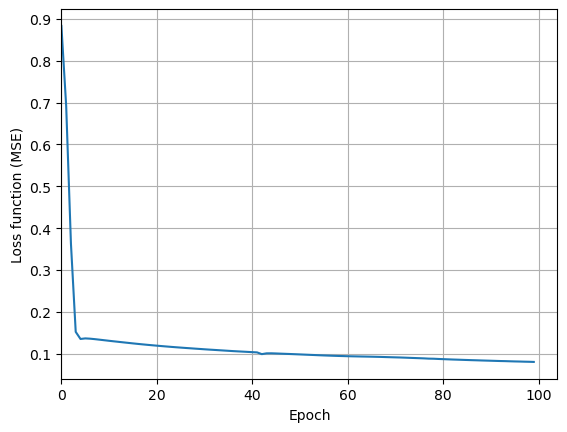

In [71]:
with torch.no_grad():
    best_pred = model(X_val_preprocessed).detach().cpu()

fix, ax = plt.subplots()
# ax.set_ylim(0,None)
print("MSE: %.2f" % best_loss_value)
print("RMSE: %.2f" % np.sqrt(best_loss_value))
ax.plot(loss_history)
ax.set_ylabel('Loss function (MSE)')
ax.set_xlabel('Epoch')
ax.set_xlim(0,None)
ax.grid()
plt.show()

# STEP 3: Make predictions and evaluate the model skill
Once the model is **trained** with the data, we can use it to make predictions. Once the predictions are ready to be used, we need to transform them back into the original dataspace. We use the inverse transform to do this.

In [72]:
y_val_predictions = model(X_val_preprocessed)
y_val_predictions_cpu = y_val_predictions.detach().to('cpu')
y_val_cpu_preprocessed = y_val_preprocessed.detach().to('cpu')
y_val_predictions_cpu = scaler_y.inverse_transform(y_val_predictions_cpu)
y_val_cpu = scaler_y.inverse_transform(y_val_cpu_preprocessed)

### Plot the predictions against the true data for the validation

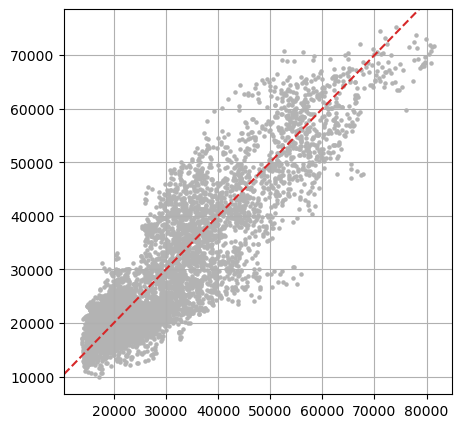

In [73]:
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(y_val_cpu,y_val_predictions_cpu, s=5, color='.7') 
ax.axline((y_val_cpu.mean(), y_val_cpu.mean()), slope=1, ls='--', color='tab:red')
ax.grid()
ax.set_xlabel('True');
ax.set_ylabel('Predictions');

### Compute RMSE and R2 score

In [74]:
rmse = sklearn.metrics.root_mean_squared_error(y_val_cpu, y_val_predictions_cpu)
r2_score = sklearn.metrics.r2_score(y_val_cpu, y_val_predictions_cpu)
print(f"RMSE: {rmse:.02f}")
print(f"R2: {r2_score:.02f}")

RMSE: 6222.76
R2: 0.77


# **XAI part**
### Now that the model is trained, you are ready to explain the model predictions

We could do this manually, but let's use a friendly library that can compute XAI* things for us. Here we use **captum**.
The next cell will install it automatically. If you have captum already installed or if you want to install it yourself, skip the next cell.

*eXplainable AI

In [16]:
!pip install --quiet --upgrade captum

> #### **QUESTION 1**
> 1. Import `ShapleyValues` from `captum.attr`
> 2. Define the attribution method by instanciating `ShapleyValues` with our neural network, and call this new object `shap`.
>
>--- 


In [75]:
from captum.attr import ShapleyValues
shap = ShapleyValues(model)

### **Single sample attribution**

We start by explaining one specific prediction.

> #### **QUESTION 2**
> - Explain one prediction of your choice that is close to the truth.
>
> - Call the resulting object **`attributions`**.
>
> ---
>
> <details>
> <summary><b>Click here for help and intermediate steps</b></summary>
>
> To do this you need to:
>
> - Choose a sample in the `indices_less_than_10pct_error` list.
> - Create an input tensor `X_sample`, corresponding to the sample ID and extracted from `X_val`.
> - Since the model expects shape *(n_samples, features)*, use `X_val[[sample_number_to_attribute]]` with two bracket pairs.
> - Put the tensor on the correct device with `.to(device)`.
> - use the `shap` method defined above to compute explaination with `shap.attribute`
> </details>


In [106]:
indices_less_than_10pct_error = np.where(np.abs(((y_val_cpu-y_val_predictions_cpu)/y_val_cpu))<.1)[0]

sample_number_to_attribute = indices_less_than_10pct_error[-10]

X_sample = X_val_preprocessed[[sample_number_to_attribute]]

attributions = shap.attribute(X_sample, target=0)

# We convert the attributions to numpy for easier handling
attributions_numpy = attributions.cpu().detach().numpy()


#### Let's plot the results

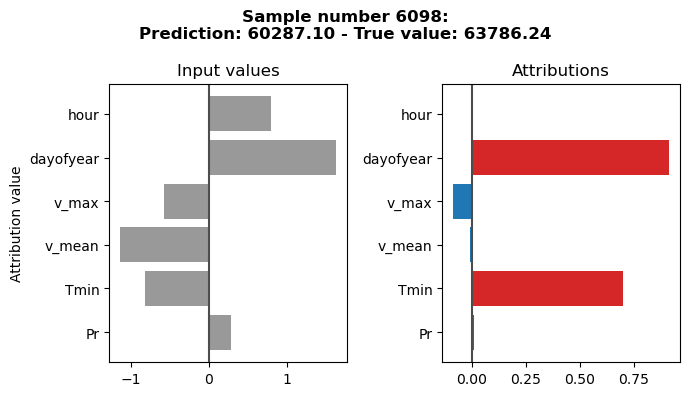

In [107]:
input_list = ['Pr','Tmin','v_mean','v_max', 'dayofyear','hour']
fig, axs= plt.subplots(1,2, figsize=(7,4))
axs[0].barh(input_list, X_sample.cpu().detach().numpy()[0], color='.6')
axs[1].barh(input_list, attributions_numpy[0].clip(min=0), color='C3')
axs[1].barh(input_list, attributions_numpy[0].clip(max=0), color='C0')
axs[0].set_ylabel('Input feature')
axs[0].set_title(f'Input values')
axs[0].set_xlabel('Transformed input values')
axs[1].set_title(f'Attributions')
axs[1].set_xlabel('SHAP values')
plt.suptitle(f'Sample number {sample_number_to_attribute}:\nPrediction: {y_val_predictions_cpu[sample_number_to_attribute][0]:.2f} - True value: {y_val_cpu[sample_number_to_attribute][0]:.2f}', weight='bold')
axs[0].axvline(0, color='.3')
axs[1].axvline(0, color='.3')

plt.tight_layout()
plt.show()

What can we see here? 

### **Multi sample attribution**

Now let's try to understand all the highest correct predictions.

> #### **QUESTION 3**
> - Explain all predictions above 60 000 kWh where the prediction of your choice that is close to the truth.
>
> - Call the resulting object **`attributions_correct_high`**.
>
> ---
>
> <details>
> <summary><b>Click here for help and intermediate steps</b></summary>
>
> To do this you need to:
>
> - Determine indices of predictions above 60 000 that are less than 10% error from the truth.
> - Create an input tensor `X_sample`, corresponding to the sample IDs of these predictions.
> - Put the tensor on the correct device with `.to(device)`.
> - use the `shap` method defined above to compute explaination with `shap.attribute`
> </details>


In [ ]:
less_than_10pct_error = np.abs(((y_val_cpu-y_val_predictions_cpu)/y_val_cpu))<.1
more_than_60000 = y_val_cpu>60000
valid_indices = np.where(less_than_10pct_error & more_than_60000)[0]

X_sample = X_val_preprocessed[valid_indices]

attributions_correct_high = shap.attribute(X_sample, target=0)

# # We convert the attributions to numpy for easier handling
attributions_correct_high_numpy = attributions_correct_high.cpu().detach().numpy()


#### Let's plot the results

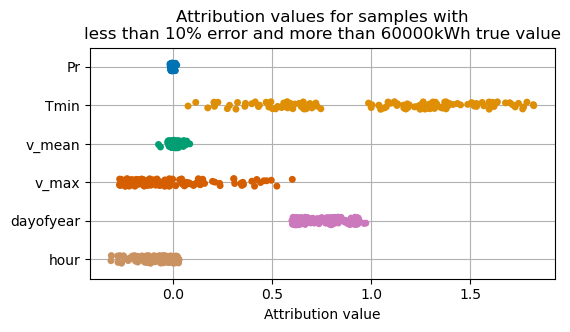

In [ ]:
fig, ax = plt.subplots(figsize=(6,3))
sns.stripplot(attributions_correct_high_numpy, orient='h', palette='colorblind',ax=ax)
ax.set_xlabel('Attribution value')
ax.set_title('Attribution values for samples with\nless than 10% error and more than 60000kWh true value')
ax.set_yticks(range(6))
ax.set_yticklabels(input_list)
plt.grid()
plt.show()

## Other things we can explore:
- What variables actually matter?
- Did the model learn an annual cycle? 
- Did the model learn a daily cycle?
- What did the model miss?

## **CONGRATULATIONS**
You have just explained your model predictions!